In [ ]:
import pandas as pd
import numpy as np
import ast
import json
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from tqdm.auto import tqdm

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style="whitegrid")

from google.colab import files
import io

print("Пожалуйста, выберите CSV файл с данными...")
#uploaded = files.upload()
#file_name = list(uploaded.keys())[0]

df = pd.read_parquet('split_label_train_V3.snappy.parquet')
#df = pd.read_parquet(io.BytesIO(uploaded[file_name]))
print(f"\nДатасет успешно загружен! Размер: {df.shape}")

Пожалуйста, выберите CSV файл с данными...

Датасет успешно загружен! Размер: (68036, 12)


In [ ]:
df1 = df

In [ ]:
df.sample(5)

,created_at,first_name,last_name,email,phone,birthday,sex,non_processing_features,realtime_features,fs_features,profile_id,entity_id
2811,2025-11-10 06:16:45.229,Раиса,None,aebgpmdpodmv@mail.ru,None,None,female,"[geoname_id:472045, browser:chrome, subdivision_1_iso_code:VOR, osfamily:android, device:smartph...","{""country"":""RU"",""is_million"":true,""tz_offset"":3,""geoname"":""Voronezh"",""geoid"":472045,""local_hour""...","[is_phone, has_order_365:3657, visited_30:3465, has_account:278, has_account:4880, visited_30:27...",56296e98-7794-3f63-b210-17c4e38c2d00,dec8bbbf61a13d7f05da8a5ad2d6ece778a52c3b3f415a3f702c915ceacdd000
55647,2026-04-04 04:42:33.895,None,None,jgdedsgicswg6@gmail.com,None,None,unknown,"[subdivision_1_iso_code:KHA, geoname_id:2022890, osfamily:android, device:smartphone]","{""country"":""RU"",""is_million"":false,""visit_count"":""0"",""tz_offset"":10,""geoname"":""Khabarovsk"",""geoi...",[],a5ba56cf-0012-3c10-8cd6-628503773815,70d55d14c43c75ddc2f0ffa3d2516d1737481ba28595d5c1fd686bb490c9696e
33760,2026-02-18 15:32:40.308,None,None,kdlj154@gmail.com,None,None,unknown,"[browser:yandex, geoname_id:554840, device:smartphone, osfamily:android, subdivision_1_iso_code:UD]","{""country"":""RU"",""is_million"":false,""tz_offset"":4,""geoname"":""Izhevsk"",""geoid"":554840,""local_hour""...","[visited_30:2275, has_click_365:3684, visited_30:1345, source_site_365:6329, has_accept_365:3684...",3ffdffb7-130d-37ba-9089-cf7bee4a2417,468b8c67a5d2f8ec5edb076477cadbd2cc37784b9b67039dfbbd00fd76ae6c21
40491,2026-03-01 20:05:40.100,None,None,ikfdggq718@gmail.com,None,None,unknown,"[device:smartphone, geoname_id:535121, browser:chrome, osfamily:android, subdivision_1_iso_code:...","{""country"":""RU"",""is_million"":false,""tz_offset"":3,""geoname"":""Lipetsk"",""geoid"":535121,""local_hour""...",[],ae1072b2-3057-3944-9d67-c12e69aaaf3e,2e21ce157f1f026625177c5145006f712652090523d8f4a3888ff723d47f2cab
64312,2026-04-29 13:57:51.939,None,None,hxltxdmzrkeehox@gmail.com,None,None,unknown,"[osfamily:android, subdivision_1_iso_code:ORL, geoname_id:515012, device:smartphone, browser:chr...","{""country"":""RU"",""is_million"":false,""visit_count"":""30"",""tz_offset"":3,""geoname"":""Orel"",""geoid"":515...","[has_view_90:6209, has_view_90:5553, has_view_90:6592, has_view_90:3756, visited_30:3349, visite...",f0ee8228-5973-3964-9ac1-7cbfe6071b88,0f80789232788a3dca44c54b073e4b6698e5cb999db2fc6efed37bec5d0c821f


In [ ]:
def parse_kv_list_to_dict(s, handle_duplicates=True, sep='|'):
    # 1. Обработка случая, когда Pandas сразу дал нам список/массив
    if isinstance(s, (list, tuple, np.ndarray)):
        if len(s) == 0 or all(pd.isna(x) for x in s):
            return {}
        items = s

    # 2. Обработка строки
    elif isinstance(s, str):
        if s == '[]' or s.strip() == '':
            return {}
        try:
            items = ast.literal_eval(s)
            if not isinstance(items, list) or len(items) == 0:
                return {}
        except (ValueError, SyntaxError):
            return {}

    # 3. Обработка обычного NaN (когда ячейка просто пустая)
    elif pd.isna(s):
        return {}

    # 4. Если что-то непонятное (число и т.д.)
    else:
        return {}

    # --- Дальше идет безопасная обработка списка items ---
    result = {}
    for item in items:
        # Пропускаем элементы списка, которые оказались NaN
        if pd.isna(item):
            continue

        if isinstance(item, str) and ':' in item:
            k, v = item.split(':', 1)
        elif isinstance(item, str):
            # Флаги без двоеточия (например, is_gmail)
            k, v = item, True
        else:
            continue

        if handle_duplicates and k in result:
            result[k] = f"{result[k]}{sep}{v}"
        else:
            result[k] = v

    return result


def parse_json_to_dict(s):
    # 1. Если Pandas уже распарсил JSON как словарь (бывает при dtype='object')
    if isinstance(s, dict):
        return s if len(s) > 0 else {}

    # 2. Обработка строки
    elif isinstance(s, str):
        if s == '{}' or s.strip() == '':
            return {}
        try:
            res = json.loads(s)
            return res if isinstance(res, dict) else {}
        except (ValueError, json.JSONDecodeError):
            return {}

    # 3. Обработка NaN
    elif pd.isna(s):
        return {}

    else:
        return {}


print("Начинаем парсинг массивов и JSON в словари...")
# Применяем функции к столбцам. Результат — столбец, где каждая ячейка это dict
np_dicts = df['non_processing_features'].apply(lambda x: parse_kv_list_to_dict(x, handle_duplicates=False))
rt_dicts = df['realtime_features'].apply(parse_json_to_dict)
fs_dicts = df['fs_features'].apply(lambda x: parse_kv_list_to_dict(x, handle_duplicates=True, sep='|'))

print("Преобразуем словари в плоские колонки (DataFrame flatten)...")
np_df = pd.json_normalize(np_dicts).add_prefix('np_')
rt_df = pd.json_normalize(rt_dicts).add_prefix('rt_')
fs_df = pd.json_normalize(fs_dicts).add_prefix('fs_')

print("Соединяем всё вместе...")
df_flat = df.drop(columns=['non_processing_features', 'realtime_features', 'fs_features'])
df_flat = pd.concat([df_flat, np_df, rt_df, fs_df], axis=1)
df = df_flat

print("Готово!")

Начинаем парсинг массивов и JSON в словари...
Преобразуем словари в плоские колонки (DataFrame flatten)...
Соединяем всё вместе...
Готово!


In [ ]:
df_flat.sample(5)

,created_at,first_name,last_name,email,phone,birthday,sex,profile_id,entity_id,np_device,np_geoname_id,np_browser,np_osfamily,np_subdivision_1_iso_code,np_is_not_russia,rt_country,rt_is_million,rt_tz_offset,rt_geoname,rt_geoid,rt_local_hour,rt_day,rt_population,rt_visit_count,fs_visited_30,fs_visited_365,fs_source_site_365,fs_has_account,fs_has_click_365,fs_has_accept_365,fs_is_phone,fs_has_order_30,fs_is_man,fs_has_order_365,fs_is_woman,fs_is_gmail,fs_source_site_30,fs_has_click_30,fs_has_accept_30,fs_is_yandex,fs_was_phone_lead,fs_mm_event_30,fs_mm_event_90,fs_postman_response_30,fs_postman_action_30,fs_postman_campaign_30,fs_postman_campaign_90,fs_postman_action_90,fs_postman_response_90,fs_postman_scenario_30,fs_postman_scenario_90,fs_has_view_90
46412,2026-03-10 23:48:30.161,None,None,gjpyylufifasvtbv@yandex.ru,None,None,unknown,7260c85e-2ccb-3e12-b7c6-b877c01b9b4c,9d9a056db2ad4cb77319d39a64af08d4a076ccec31e79755dba1aff9d6e35c43,smartphone,501175,chrome,android,ROS,NaN,RU,True,3.0,Rostov-na-Donu,501175.0,2.0,2.0,1130305.0,NaN,1921|2632|1345|572|4009,1813|3265,6659|6897|4211,2492|4129|1345|889|4009|1696|3210|2286|2953,3684|3824,3684|3824,NaN,NaN,True,4009,True,True,6659|4211,3824,3824,True,NaN,NaN,NaN,ok|err,smtp_sent,exchange|xmail,xmail|exchange,smtp_sent,err|ok,lost-basket|inactivity-lost-basket-reminder,lost-basket|inactivity-lost-basket-reminder,NaN
51898,2026-03-25 06:52:57.927,Денис,None,jmbp011sj@mail.ru,None,None,male,8d796b6b-4398-3b3a-88d5-a9b17befcc93,f1d615c5e0142157d65f587af54ce354b0443f7210726244c49a7c19f9327d91,smartphone,511196,NaN,ios,PER,NaN,RU,False,5.0,Perm,511196.0,11.0,2.0,982419.0,2,1345,NaN,6333,899,3824,3824|3827,NaN,NaN,True,NaN,NaN,NaN,6333,3824,3827|3824,NaN,NaN,NaN,NaN,err,smtp_sent,exchange,exchange,smtp_sent,err,NaN,NaN,NaN
66270,2026-05-06 09:37:23.992,Кира,None,vvczifgixyhir86@gmail.com,79776164664,None,female,33e9ce4c-c903-3aa6-87bb-f948914a3fe4,38917ad8c6df03f95a79a2a877ae9750973a0fb23701dee272189de6b0981c80,smartphone,554234,NaN,ios,KGD,NaN,RU,False,2.0,Kaliningrad,554234.0,11.0,2.0,475056.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31076,2026-02-13 05:22:59.994,None,None,dorobvqbecoxlmd5137@gmail.com,None,None,unknown,66d8b50d-d195-394d-b782-9fef1870597d,a511956cdef12b924f5a43c5984170eed2293b29e45aba4777adbd9b91a5575e,smartphone,NaN,chrome,android,VLG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1345,NaN,6659|4211|4253|6333,2219|3210|2286|2741|1345,5506|7088|7023|4078|3392,5506|7088,NaN,NaN,NaN,NaN,True,True,4253|6659|6333,7088,7088,NaN,NaN,NaN,NaN,ok,smtp_sent,exchange,exchange,smtp_sent,err|ok,NaN,NaN,NaN
17487,2026-01-05 08:37:07.780,None,None,hyywgohmrkaxxtvf7@gmail.com,None,None,unknown,056ec8c8-642e-3423-a716-5fe36624727d,0c75d9231ac4fc34e65e883f51475f289f515b1558b66c3713d376d777c77a6d,smartphone,1512569,chrome,android,TK,True,UZ,True,5.0,Tashkent,1512569.0,13.0,0.0,1978028.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_flat.describe()

,created_at,rt_tz_offset,rt_geoid,rt_local_hour,rt_day,rt_population
count,68036,53806.000000,5.405000e+04,54050.000000,54050.000000,5.401700e+04
mean,2026-02-11 19:24:37.635990528,3.912984,1.131361e+06,14.226975,3.074376,1.192286e+06
min,2025-11-01 00:27:04.995000,-9.000000,5.365400e+04,0.000000,0.000000,3.960000e+02
25%,2026-01-04 07:31:59.484749824,3.000000,5.035500e+05,10.000000,1.000000,3.276080e+05
50%,2026-02-19 06:56:36.157499904,3.000000,5.884090e+05,15.000000,3.000000,6.323720e+05
75%,2026-03-22 06:52:10.172499968,5.000000,1.510853e+06,20.000000,5.000000,1.172070e+06
max,2026-05-11 23:37:47.651000,12.000000,1.203184e+07,23.000000,6.000000,2.487450e+07
std,NaN,2.292911,8.954192e+05,6.203777,2.021691,2.009507e+06


In [ ]:
df_flat.columns

Index(['created_at', 'first_name', 'last_name', 'email', 'phone', 'birthday',
       'sex', 'profile_id', 'entity_id', 'np_device', 'np_geoname_id',
       'np_browser', 'np_osfamily', 'np_subdivision_1_iso_code',
       'np_is_not_russia', 'rt_country', 'rt_is_million', 'rt_tz_offset',
       'rt_geoname', 'rt_geoid', 'rt_local_hour', 'rt_day', 'rt_population',
       'rt_visit_count', 'fs_visited_30', 'fs_visited_365',
       'fs_source_site_365', 'fs_has_account', 'fs_has_click_365',
       'fs_has_accept_365', 'fs_is_phone', 'fs_has_order_30', 'fs_is_man',
       'fs_has_order_365', 'fs_is_woman', 'fs_is_gmail', 'fs_source_site_30',
       'fs_has_click_30', 'fs_has_accept_30', 'fs_is_yandex',
       'fs_was_phone_lead', 'fs_mm_event_30', 'fs_mm_event_90',
       'fs_postman_response_30', 'fs_postman_action_30',
       'fs_postman_campaign_30', 'fs_postman_campaign_90',
       'fs_postman_action_90', 'fs_postman_response_90',
       'fs_postman_scenario_30', 'fs_postman_scenario_90

In [ ]:
df_flat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68036 entries, 0 to 68035
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   created_at                 68036 non-null  datetime64[ns]
 1   first_name                 18479 non-null  object        
 2   last_name                  1621 non-null   object        
 3   email                      68036 non-null  object        
 4   phone                      4966 non-null   object        
 5   birthday                   407 non-null    object        
 6   sex                        67984 non-null  object        
 7   profile_id                 68036 non-null  object        
 8   entity_id                  68036 non-null  object        
 9   np_device                  65332 non-null  object        
 10  np_geoname_id              54864 non-null  object        
 11  np_browser                 44591 non-null  object        
 12  np_o

In [ ]:
df = df_flat

In [ ]:
# Сначала считаем количество уникальных профилей для каждого entity_id
entity_profile_counts = df.groupby('entity_id')['profile_id'].nunique()

# Создаём отображение entity_id → тип
entity_type_map = entity_profile_counts.apply(
    lambda x: 'multi_profile' if x > 1 else 'single_profile'
).to_dict()

# Применяем отображение к датасету
df['entity_type'] = df['entity_id'].map(entity_type_map)

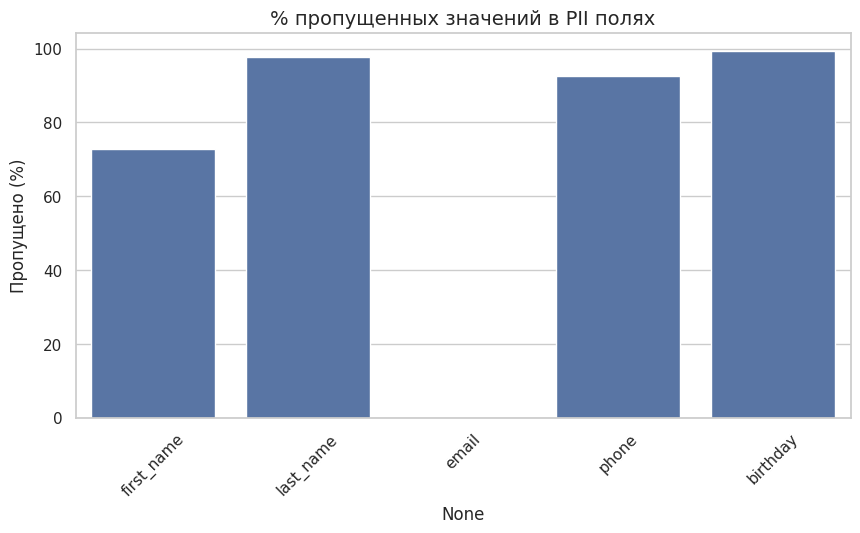


Вывод: Точное совпадение по ФИО и телефону покроет лишь малую часть дубликатов.
Нужно делать упор на email домен, гео и поведения (fs_features).


In [ ]:
# 1. Анализ разреженности PII (Персональных идентифицирующих данных)
pii_cols = ['first_name', 'last_name', 'email', 'phone', 'birthday']
missing_pii = df[pii_cols].isnull().mean() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pii.index, y=missing_pii.values)
plt.title('% пропущенных значений в PII полях', fontsize=14)
plt.ylabel('Пропущено (%)')
plt.xticks(rotation=45)
plt.show()

print("\nВывод: Точное совпадение по ФИО и телефону покроет лишь малую часть дубликатов.")
print("Нужно делать упор на email домен, гео и поведения (fs_features).")

Всего уникальных профилей: 61927
Всего уникальных сущностей (людей): 53369
Сущностей с дубликатами (multi_profile): 8073


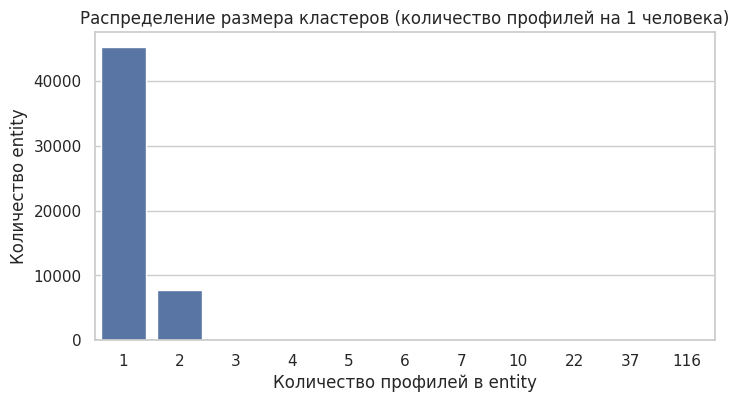

In [ ]:
# Анализ структуры дубликатов (Target Variable)
# Сколько уникальных entity и профилей
n_profiles = df['profile_id'].nunique()
n_entities = df['entity_id'].nunique()
n_multi_entities = df[df['entity_type'] == 'multi_profile']['entity_id'].nunique()

print(f"Всего уникальных профилей: {n_profiles}")
print(f"Всего уникальных сущностей (людей): {n_entities}")
print(f"Сущностей с дубликатами (multi_profile): {n_multi_entities}")

# Размер кластеров дубликатов
cluster_sizes = df[df['entity_type'] == 'multi_profile'].groupby('entity_id')['profile_id'].nunique()
cluster_sizes = df.groupby('entity_id')['profile_id'].nunique()
plt.figure(figsize=(8, 4))
sns.countplot(x=cluster_sizes.values)
plt.title('Распределение размера кластеров (количество профилей на 1 человека)')
plt.xlabel('Количество профилей в entity')
plt.ylabel('Количество entity')
plt.show()

In [ ]:
# Берем только multi_profile сущности
multi_df = df[df['entity_type'] == 'multi_profile']

def check_determinism(group, col):
    vals = group[col].dropna().unique()
    if len(vals) <= 1:
        return True # Детерминировано (или оба пустые)
    return False # Не детерминировано!

determinism_results = {}
for col in ['first_name', 'last_name', 'email', 'phone', 'birthday']:
    # Группируем по entity_id и проверяем уникальность
    is_det = multi_df.groupby('entity_id').apply(lambda x: check_determinism(x, col)).mean() * 100
    determinism_results[col] = is_det

det_df = pd.DataFrame.from_dict(determinism_results, orient='index', columns=['% детерминированных entity'])
print("Процент сущностей, где анонимизация отработала детерминированно (одинаковые значения внутри кластера):")
display(det_df)

# Важно проверить: если не детерминировано, то почему? (разные исходные данные у одного человека или ошибка анонимизации?)
non_det_phone = multi_df.groupby('entity_id').filter(lambda x: x['phone'].dropna().nunique() > 1)[['entity_id', 'phone']].drop_duplicates().head(5)
print("\nПример не-детерминированных телефонов (человек завел 2 разных номера?):")
display(non_det_phone)

/tmp/ipykernel_2708/637602058.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  is_det = multi_df.groupby('entity_id').apply(lambda x: check_determinism(x, col)).mean() * 100
/tmp/ipykernel_2708/637602058.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  is_det = multi_df.groupby('entity_id').apply(lambda x: check_determinism(x, col)).mean() * 100
/tmp/ipykernel_2708/637602058.py:13: DeprecationWarnin

Процент сущностей, где анонимизация отработала детерминированно (одинаковые значения внутри кластера):


/tmp/ipykernel_2708/637602058.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  is_det = multi_df.groupby('entity_id').apply(lambda x: check_determinism(x, col)).mean() * 100


,% детерминированных entity
first_name,97.101449
last_name,99.925678
email,0.000000
phone,99.368265
birthday,100.000000



Пример не-детерминированных телефонов (человек завел 2 разных номера?):


,entity_id,phone
1249,73a08155ef99fe513f5d7a935305fa03e8001e38c5ac144933d608b8c333c3b2,79851731682
1250,73a08155ef99fe513f5d7a935305fa03e8001e38c5ac144933d608b8c333c3b2,79198381731
2278,784f3bdd48dfd74811e7145e9673ec7b65f58eebd07cdbcdaaba8723f63ed81c,79263892241
2281,784f3bdd48dfd74811e7145e9673ec7b65f58eebd07cdbcdaaba8723f63ed81c,79161412718
2304,10ca463137d10d509b3c9e534b5ad840aced186668edffb14cb0dd8cc3fd1b21,79224714339


### New


In [ ]:
# Настройка графиков
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

# Вспомогательная функция для подсчета элементов в строках вида "val1|val2|val3"
def count_pipe_elements(x):
    if pd.isna(x) or x == '':
        return 0
    return len(str(x).split('|'))

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")

Размер датасета: 68036 строк, 53 колонок


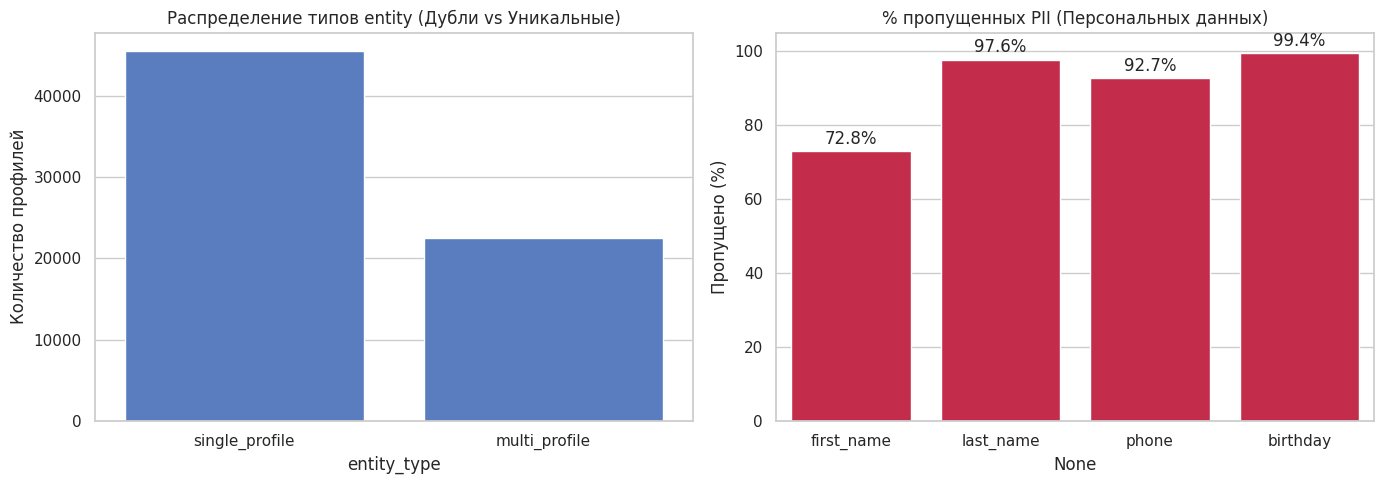

ВЫВОД: Точный match по ФИО/Телефону не сработает. Телефон есть только у 7%, ФИО частично пустые.


In [ ]:
# Анализ целевой переменной и проблема разреженности PII

# 1. Баланс классов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='entity_type', ax=axes[0])
axes[0].set_title('Распределение типов entity (Дубли vs Уникальные)')
axes[0].set_ylabel('Количество профилей')

# 2. Полнота PII данных (Ключевая проблема!)
pii_cols = ['first_name', 'last_name', 'phone', 'birthday']
missing_pii = df[pii_cols].isnull().mean() * 100

sns.barplot(x=missing_pii.index, y=missing_pii.values, ax=axes[1], color='crimson')
axes[1].set_title('% пропущенных PII (Персональных данных)')
axes[1].set_ylabel('Пропущено (%)')
axes[1].set_ylim(0, 105)
for i, v in enumerate(missing_pii.values):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()
print("ВЫВОД: Точный match по ФИО/Телефону не сработает. Телефон есть только у 7%, ФИО частично пустые.")

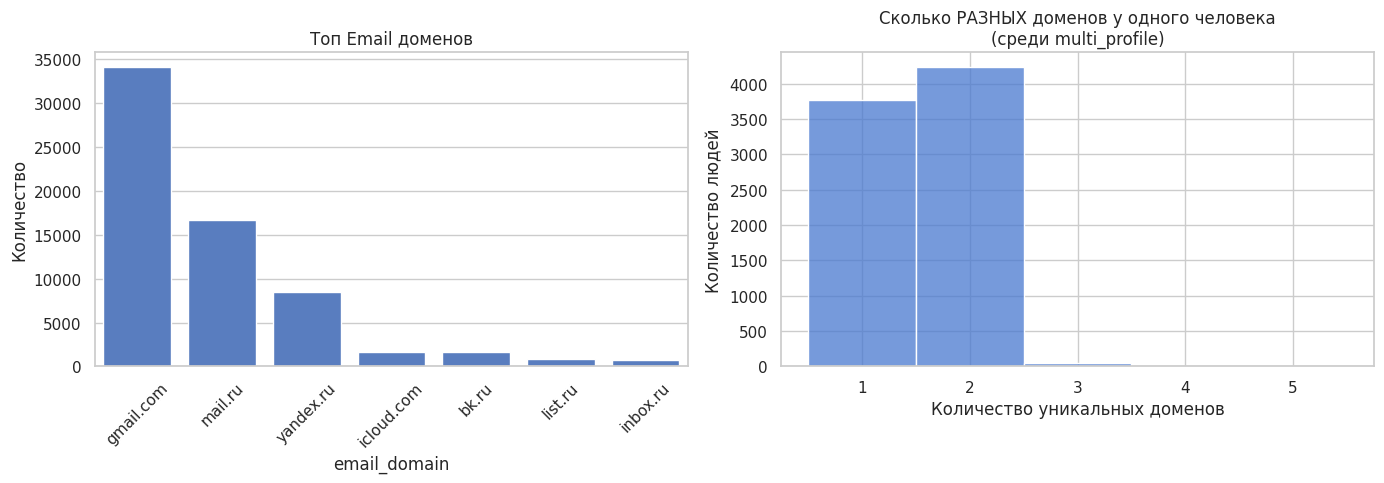

ВЫВОД: Если у дубликатов почти всегда 1 домен, признак 'совпадение домена' = очень сильный базовый фильтр.


In [ ]:
# Извлечение сигналов из Email (Наш главный PII-спаситель)

# Извлекаем домен
df['email_domain'] = df['email'].str.split('@').str[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Топ доменов
top_domains = df['email_domain'].value_counts().head(7)
sns.barplot(x=top_domains.index, y=top_domains.values, ax=axes[0])
axes[0].set_title('Топ Email доменов')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

# Совпадает ли домен у дубликатов? (Гипотеза: человек не меняет почту)
# Группируем по entity_id и смотрим количество уникальных доменов
domain_uniq_per_entity = df.groupby('entity_id')['email_domain'].nunique()
# Берем только тех, у кого есть дубли (multi)
multi_entities = df[df['entity_type'] == 'multi_profile']['entity_id'].unique()
#multi_domain_uniq = domain_uniq_per_entity[multi_entities.index.isin(multi_entities)]
multi_domain_uniq = domain_uniq_per_entity[domain_uniq_per_entity.index.isin(multi_entities)]


sns.histplot(multi_domain_uniq, bins=3, ax=axes[1], discrete=True)
axes[1].set_title('Сколько РАЗНЫХ доменов у одного человека\n(среди multi_profile)')
axes[1].set_xlabel('Количество уникальных доменов')
axes[1].set_ylabel('Количество людей')

plt.tight_layout()
plt.show()
print("ВЫВОД: Если у дубликатов почти всегда 1 домен, признак 'совпадение домена' = очень сильный базовый фильтр.")

In [ ]:
df.sample(5)

,created_at,first_name,last_name,email,phone,birthday,sex,profile_id,entity_id,np_device,np_geoname_id,np_browser,np_osfamily,np_subdivision_1_iso_code,np_is_not_russia,rt_country,rt_is_million,rt_tz_offset,rt_geoname,rt_geoid,rt_local_hour,rt_day,rt_population,rt_visit_count,fs_visited_30,fs_visited_365,fs_source_site_365,fs_has_account,fs_has_click_365,fs_has_accept_365,fs_is_phone,fs_has_order_30,fs_is_man,fs_has_order_365,fs_is_woman,fs_is_gmail,fs_source_site_30,fs_has_click_30,fs_has_accept_30,fs_is_yandex,fs_was_phone_lead,fs_mm_event_30,fs_mm_event_90,fs_postman_response_30,fs_postman_action_30,fs_postman_campaign_30,fs_postman_campaign_90,fs_postman_action_90,fs_postman_response_90,fs_postman_scenario_30,fs_postman_scenario_90,fs_has_view_90,entity_type,email_domain
45201,2026-03-09 04:09:20.497,None,None,btikfhpcoxmobuytoy62@gmail.com,None,None,unknown,4409060a-3a75-34c8-8d5a-fe7a7dd6b80f,57ea3c1c4bcb88dfbbd3bac4b46e4a43e070ec569f427251ebf0720493ed1652,smartphone,1512569,chrome,android,TK,True,UZ,True,5.0,Tashkent,1512569.0,9.0,0.0,1978028.0,NaN,NaN,NaN,7095,NaN,3827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7095,3827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,single_profile,gmail.com
14305,2025-12-29 02:40:10.470,None,None,joaytyvvenewpvq617@gmail.com,None,None,unknown,c6e68331-a253-3f04-8a4d-1090ea350ec8,5b8ee7c580a63bc5987a546408281931961ef63d7866b9deba9bd3cc7bf5c0f4,smartphone,NaN,chrome,android,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6871,2219,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,single_profile,gmail.com
32918,2026-02-16 16:22:28.181,None,None,akmzhgtz9403@gmail.com,None,None,unknown,bedfe1cd-ae1a-3190-a438-62d3a299947f,a1905a7b0de75ef98a0b880f24197019752ed5668366db22812d8ebabb41049a,smartphone,479123,chrome,android,ULY,NaN,RU,False,4.0,Ulyanovsk,479123.0,20.0,0.0,626540.0,NaN,1345,NaN,6976,1345,3827,3827,NaN,NaN,NaN,NaN,NaN,True,6976,3827,3827,NaN,NaN,NaN,NaN,ok,smtp_sent,exchange,exchange,smtp_sent,ok,NaN,NaN,NaN,single_profile,gmail.com
8564,2025-12-07 08:33:40.149,None,None,rzbyu.kunthx.99@gmail.com,None,None,unknown,243572a5-5478-3207-95ef-f4e57021f504,d29506ec5b3fcfd7fe52c18456795ddbcfbe4e637dc8b65fd2babc14e8974ced,smartphone,2022890,NaN,android,KHA,NaN,RU,False,10.0,Khabarovsk,2022890.0,18.0,6.0,618150.0,NaN,NaN,NaN,2953,2487|278|1622,3684,3684,NaN,NaN,NaN,NaN,NaN,True,2953,3684,3684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,single_profile,gmail.com
36096,2026-02-23 06:35:28.997,None,None,ebzlrpjrdqw379@gmail.com,None,None,unknown,f7994525-5e20-362d-9a9f-6bc3256f17be,109a21864236911e54a8030623c19768b33fa44737265328237d92d366fcaff2,smartphone,NaN,chrome,android,KEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,multi_profile,gmail.com


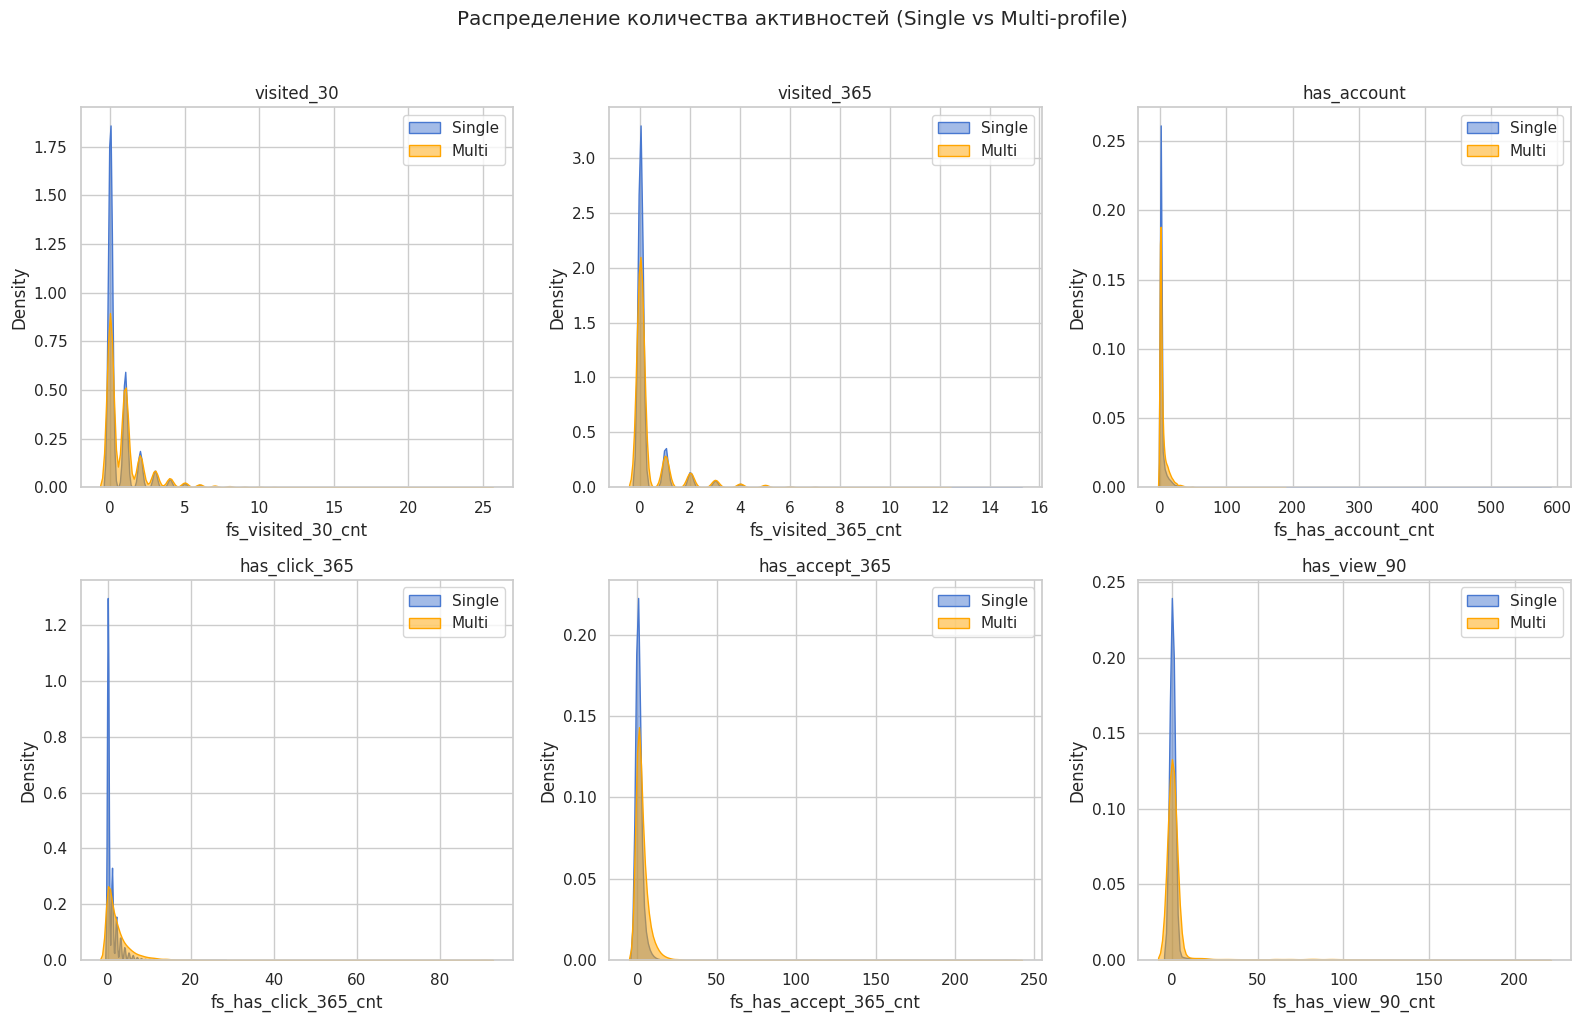

ВЫВОД: Дубли (multi) обычно более активные пользователи (у них больше визитов и кликов), так как они логинились с разных устройств.


In [ ]:
# Анализ поведенческих признаков (FS Features)

# Создаем временные колонки с количеством элементов (кардинальность)
fs_list_cols = ['fs_visited_30', 'fs_visited_365', 'fs_has_account',
                'fs_has_click_365', 'fs_has_accept_365', 'fs_has_view_90']

for col in fs_list_cols:
    df[f'{col}_cnt'] = df[col].apply(count_pipe_elements)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(fs_list_cols):
    cnt_col = f'{col}_cnt'
    # Строим распределение для single и multi
    sns.kdeplot(data=df[df['entity_type']=='single_profile'], x=cnt_col, ax=axes[i], label='Single', fill=True, alpha=0.5)
    sns.kdeplot(data=df[df['entity_type']=='multi_profile'], x=cnt_col, ax=axes[i], label='Multi', fill=True, alpha=0.5, color='orange')
    axes[i].set_title(col.replace('fs_', ''))
    axes[i].legend()

plt.suptitle('Распределение количества активностей (Single vs Multi-profile)', y=1.02)
plt.tight_layout()
plt.show()
print("ВЫВОД: Дубли (multi) обычно более активные пользователи (у них больше визитов и кликов), так как они логинились с разных устройств.")

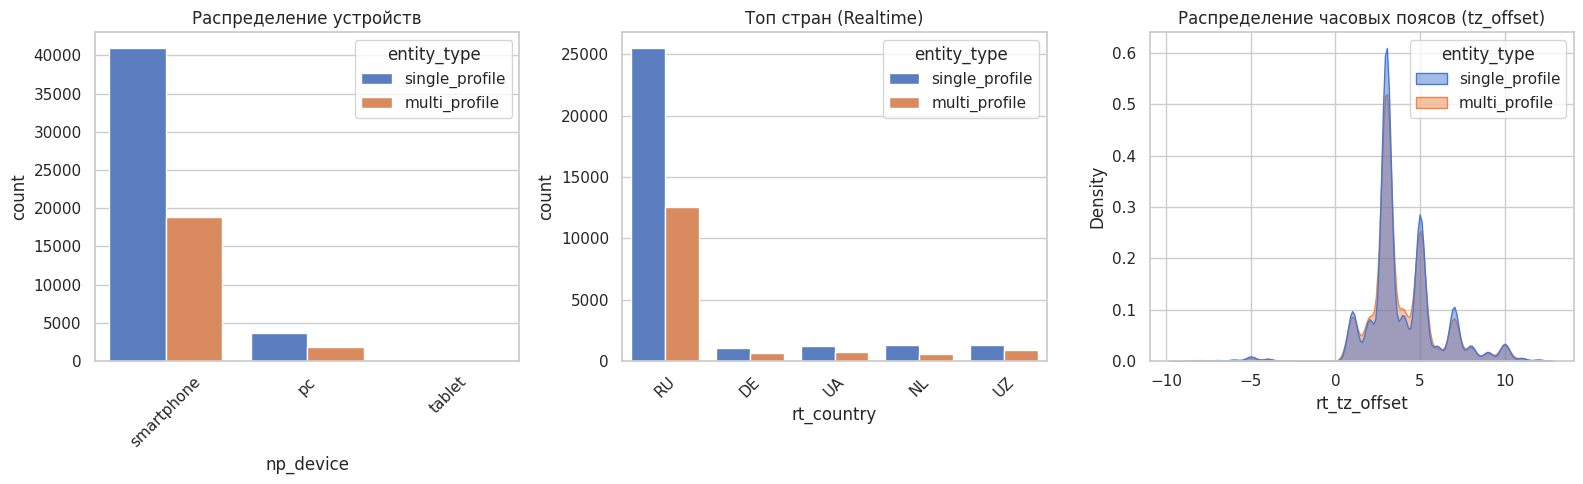

ВЫВОД: Дубликат может зайти с мобильного (смартфон) и с ПК. Смена устройства — частый паттерн дублирования.


In [ ]:
# Контекст и Гео (Устройства и Города)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Устройства
sns.countplot(data=df, x='np_device', hue='entity_type', ax=axes[0], order=df['np_device'].value_counts().index)
axes[0].set_title('Распределение устройств')
axes[0].tick_params(axis='x', rotation=45)

# 2. Страны (из rt_country)
top_countries = df['rt_country'].value_counts().head(5).index
sns.countplot(data=df[df['rt_country'].isin(top_countries)], x='rt_country', hue='entity_type', ax=axes[1])
axes[1].set_title('Топ стран (Realtime)')
axes[1].tick_params(axis='x', rotation=45)

# 3. Часовая зона (tz_offset) - важно для понимания, живут ли они в одном часовом поясе
sns.kdeplot(data=df, x='rt_tz_offset', hue='entity_type', ax=axes[2], fill=True, alpha=0.5, common_norm=False)
axes[2].set_title('Распределение часовых поясов (tz_offset)')

plt.tight_layout()
plt.show()
print("ВЫВОД: Дубликат может зайти с мобильного (смартфон) и с ПК. Смена устройства — частый паттерн дублирования.")

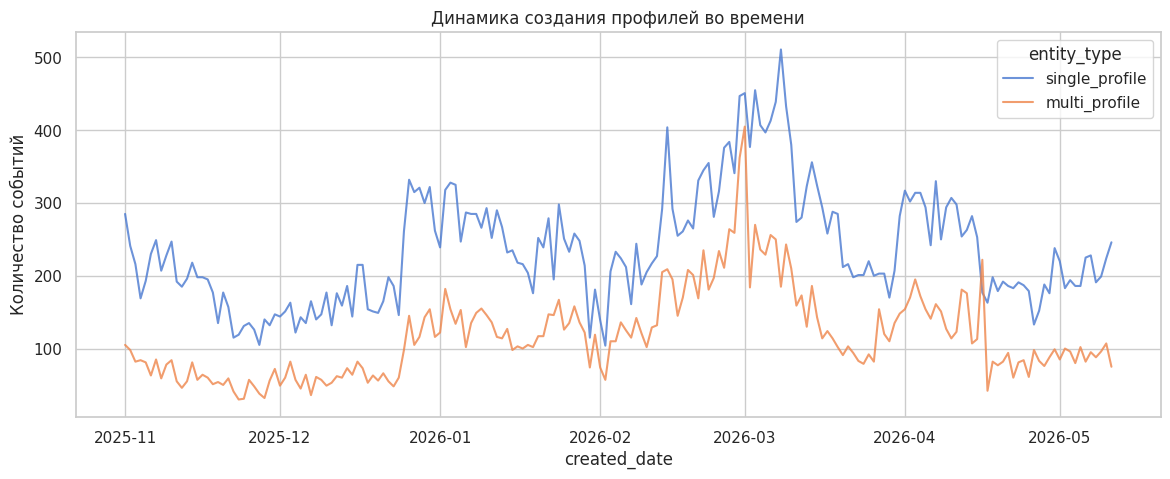

ВЫВОД: Если дубли появляются в один день - это признак бага фронтенда или повторной регистрации.


In [ ]:
# Временной паттерн (Time Delta)

# Смотрим, в какой период создавались дубликаты
df['created_date'] = df['created_at'].dt.date

plt.figure(figsize=(14, 5))
# Агрегируем по дням
daily_counts = df.groupby(['created_date', 'entity_type']).size().unstack(fill_value=0)
daily_counts[['single_profile', 'multi_profile']].plot(ax=plt.gca(), alpha=0.8)
plt.title('Динамика создания профилей во времени')
plt.ylabel('Количество событий')
plt.show()

print("ВЫВОД: Если дубли появляются в один день - это признак бага фронтенда или повторной регистрации.")

In [ ]:
# df_flat = df_flat.drop(columns=['birthday', 'fs_is_phone', 'fs_has_order_30', 'fs_is_man', 'fs_has_order_365', 'fs_is_yandex',
#                                 'fs_was_phone_lead', 'fs_postman_scenario_30', 'fs_postman_scenario_90', 'fs_has_view_90', 'last_name'])

df_flat = df_flat.drop(columns=['last_name', 'birthday'])

### Главные выводы для построения модели (на основе EDA):

1. **Архитектура модели:** Модель должна сравнивать **пары** `(Профиль А, Профиль Б)`.
2. **Базовые фильтры (Блокирующие правила - Blocking):**
    - Чтобы не сравнивать все 68k профилей друг с другом (это ~2.3 миллиарда пар!), мы должны сначала отфильтровать кандидатов.
    - _Правило 1:_ Сравниваем только профили с **совпадающим email-доменом**.
    - _Правило 2:_ Сравниваем профили с **совпадающим префиксом телефона** (первые 4-5 цифр).
3. **Фичи для PII:**
    - `name_match`: совпадают ли анонимизированные `first_name` (1/0).
    - `phone_prefix_match`: совпадают ли код страны и оператора (1/0).
4. **Фичи для Гео и Контекста (Самые простые):**
    - `same_device`: совпадает ли `np_device` (1/0).
    - `same_os`: совпадает ли `np_osfamily` (1/0).
    - `tz_offset_diff`: разница в часовых поясах `rt_tz_offset` (абсолютное значение).
    - `geoid_match`: совпадает ли `rt_geoid` (1/0).
5. **Фичи для FS Features (Самые мощные!):** Здесь нельзя просто делать `==`. Нужны метрики пересечения множеств. Для каждой пары профилей нужно посчитать:
    - **Jaccard Similarity** для множества сайтов из `fs_visited_365`. (Разбить строку по `|`, превратить в set, найти пересечение).
    - **Jaccard Similarity** для множества аккаунтов из `fs_has_account`.
    - **Количество общих элементов** в `fs_has_click_365`.
    - _Инсайт:_ Если два профиля заходили на один и тот же замаскированный site_id (например, `1345`) в рамках `fs_has_account`, вероятность того, что это один человек, близка к 100%, даже если имена и гео разные.

## Как вариант (еще думаю над этим):

Машина не умеет "смотреть на два профиля и понимать, что это один человек". Она умеет только смотреть на строку с числами (признаками) и выдавать вероятность.

Эти две функции превращают список независимых профилей (строк) в таблицу пар (строк), где каждая строка — это вопрос машине: "Это один и тот же человек или нет?".

Если мы захотим сравнить _каждый_ 68 000 профиль с _каждым_, нам придется сгенерировать: 68000×67999/2≈2.3 миллиарда пар

**Blocking (блокировка) — это фильтр, чтобы не делать бессмысленную работу.** Логика проста: если у Профиля А почта `vasya@mail.ru`, а у Профиля Б — `petya@gmail.com`, **они никогда не будут дубликатами**. Люди редко меняют почтовый провайдер между визитами.

Поэтому мы делим все 68 000 профилей на "кучки" (блоки) по домену:

- Кучка `@mail.ru` (например, 20 000 человек)
- Кучка `@gmail.com` (например, 30 000 человек)
- Кучка `@bk.ru` (например, 5 000 человек)

И мы сравниваем профили **только внутри одной кучки**. Вместо 2.3 миллиарда пар мы получаем, скажем, **1.1 миллиона пар**. С этим Colab справится за пару минут.

Как мы выяснили на этапе EDA, обычные данные (ФИО, телефон) заполнены меньше чем у 10% людей. Точного совпадения там нет. Зато у людей есть история посещений (`fs_visited_365`, `fs_has_account` и т.д.).

Выглядят они так:

- Профиль А: `fs_has_account` = `"1345|2968|1805"`
- Профиль Б: `fs_has_account` = `"1345|4880|9021"`

Мы не можем просто спросить: `"А" равно "Б"?` (Ответ будет `False`, хотя человек один). Мы не можем просто посчитать количество сайтов (у обоих по 3 сайта — это не значит, что они совпадают).

**Метрика Жаккара — это математический способ измерить "похожесть" двух списков.** Формула: _(Количество общих элементов) / (Количество уникальных элементов в обоих списках вместе)_

1. Пересечение (что есть у обоих): только сайт `1345`. (1 элемент)
2. Объединение (все сайты): `1345, 2968, 1805, 4880, 9021`. (5 элементов)
3. Жаккард = 1/5=0.2 (или 20% похожести).

Функция `_fast_jaccard` автоматизирует это: она берет строку с разделителями `|`, бьет ее на множества и выдает число от 0.0 (ничего общего) до 1.0 (полное совпадение списков).

Создан **датасет final_pairs_df для обучения модели машинного обучения**

Было: Таблица профилей. Строка = один человек.

**Стало:** Таблица сравнений. Строка = пара (Профиль А и Профиль Б).

|profile_id_1|profile_id_2|jaccard_fs_has_account|jaccard_fs_visited_365|...|is_match|
|---|---|---|---|---|---|
|aaa-bbb|ccc-ddd|0.0|0.1|...|**0** (Разные люди)|
|aaa-bbb|eee-fff|0.85|0.9|...|**1** (Дубликат!)|
|aaa-bbb|ggg-hhh|0.0|0.0|...|**0** (Разные люди)|

Теперь можно дать эту таблицу алгоритму и сказать: _"Посмотри на колонку `jaccard_fs_has_account`. Видишь, когда там число близко к 1, колонка `is_match` почти всегда равна 1? Запомни это! Запомни и другие закомерности!"_

Модель обучится, и потом, когда придет _новый, неизвестный_ профиль, вы сгенерируете для него пары с существующими, посчитаете Жаккара, скормите модели, и она скажет: "С вероятностью 98% это дубликат профиля X".

In [ ]:
!pip install -q catboost optuna ucimlrepo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 39.6 MB/s eta 0:00:00


0. Оптимизация массивов fs_ (перевод в множества)...

1. Генерация сбалансированной выборки пар...


Позитивные пары (1):   0%|          | 0/8073 [00:00<?, ?it/s]

Негативные пары (0):   0%|          | 0/780 [00:00<?, ?it/s]

   -> Итого пар для обучения: 75094 (Доля дубликатов: 50%)

2. Вычисление попарных признаков...


  Категории:   0%|          | 0/30 [00:00<?, ?it/s]

  Жаккар:   0%|          | 0/12 [00:00<?, ?it/s]


3. Подготовка матрицы X и y...

4. Обучение CatBoost...
0:	learn: 0.9958008	test: 0.9956486	best: 0.9956486 (0)	total: 412ms	remaining: 3m 25s
100:	learn: 0.9977530	test: 0.9977021	best: 0.9977057 (92)	total: 35.8s	remaining: 2m 21s
200:	learn: 0.9980216	test: 0.9979165	best: 0.9979212 (197)	total: 1m 8s	remaining: 1m 42s
300:	learn: 0.9981426	test: 0.9979960	best: 0.9979960 (300)	total: 1m 42s	remaining: 1m 7s
bestTest = 0.9980287974
bestIteration = 346
Shrink model to first 347 iterations.

5. Поиск лучшего порога и оценка...

Лучший порог: 0.50

--- ОТЧЕТ ---
              precision    recall  f1-score   support

  Разные (0)       0.97      0.94      0.95     14203
   Дубли (1)       1.00      1.00      1.00    319635

    accuracy                           1.00    333838
   macro avg       0.98      0.97      0.98    333838
weighted avg       1.00      1.00      1.00    333838



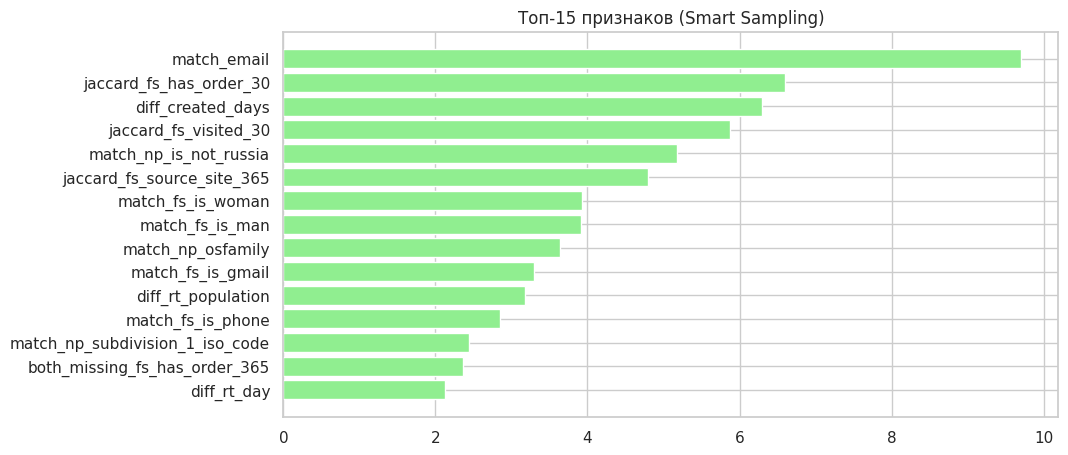

In [ ]:
import itertools
import gc
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt


# ШАГ 0: ОПТИМИЗАЦИЯ ИСХОДНЫХ ДАННЫХ В ПАМЯТИ
print("0. Оптимизация массивов fs_ (перевод в множества)...")
set_cols_opt = ['fs_visited_30', 'fs_visited_365', 'fs_source_site_365', 'fs_has_account',
                'fs_has_click_365', 'fs_has_accept_365', 'fs_has_order_30', 'fs_has_order_365',
                'fs_source_site_30', 'fs_has_click_30', 'fs_has_accept_30', 'fs_has_view_90']

for col in set_cols_opt:
    df_flat[col] = df_flat[col].apply(lambda x: frozenset(x.split('|')) if isinstance(x, str) and x else None)

if 'email_domain' not in df_flat.columns:
    df_flat['email_domain'] = df_flat['email'].str.split('@').str[-1]


# ШАГ 1: УМНАЯ ГЕНЕРАЦИЯ ПАР (БЕЗ OOM)

print("\n1. Генерация сбалансированной выборки пар...")
multi_profiles = df_flat[df_flat['entity_type'] == 'multi_profile']

# Собираем Позитивные пары (дубликаты = 1)
pos_pairs = []
for entity_id, group in tqdm(multi_profiles.groupby('entity_id'), desc="Позитивные пары (1)"):
    pids = group['profile_id'].tolist()
    if len(pids) >= 2:
        pos_pairs.extend(itertools.combinations(pids, 2))

pos_df = pd.DataFrame(pos_pairs, columns=['profile_id_1', 'profile_id_2'])
pos_df['is_match'] = 1

# Собираем Негативные пары (не дубли = 0) в размере 1 к 1
target_neg_count = len(pos_df)
neg_pairs = []
domains = df_flat['email_domain'].dropna().unique()
np.random.shuffle(domains)

for dom in tqdm(domains, desc="Негативные пары (0)"):
    if len(neg_pairs) >= target_neg_count:
        break
    pids = df_flat[df_flat['email_domain'] == dom]['profile_id'].tolist()
    if len(pids) >= 2:
        sample_size = min(100, len(pids))
        random_pairs = list(itertools.combinations(np.random.choice(pids, size=sample_size, replace=False), 2))
        neg_pairs.extend(random_pairs)

neg_df = pd.DataFrame(neg_pairs[:target_neg_count], columns=['profile_id_1', 'profile_id_2'])
neg_df['is_match'] = 0

# Объединяем и перемешиваем
pairs_df = pd.concat([pos_df, neg_df]).sample(frac=1, random_state=42).reset_index(drop=True)
del pos_df, neg_df, neg_pairs, pos_pairs; gc.collect()
print(f"   -> Итого пар для обучения: {len(pairs_df)} (Доля дубликатов: {pairs_df['is_match'].mean()*100:.0f}%)")


# ШАГ 2: ГЕНЕРАЦИЯ ПОПАРНЫХ ПРИЗНАКОВ

def generate_pairwise_features(pairs_df, base_df):
    print("\n2. Вычисление попарных признаков...")

    cat_cols = ['first_name', 'email', 'phone', 'sex', 'np_device', 'np_browser', 'np_osfamily',
                'np_subdivision_1_iso_code', 'rt_country', 'rt_geoname', 'np_is_not_russia', 'rt_is_million',
                'fs_is_phone', 'fs_is_man', 'fs_is_woman', 'fs_is_gmail', 'fs_is_yandex', 'fs_was_phone_lead',
                'fs_mm_event_30', 'fs_mm_event_90', 'fs_postman_response_30', 'fs_postman_action_30',
                'fs_postman_campaign_30', 'fs_postman_campaign_90', 'fs_postman_action_90',
                'fs_postman_response_90', 'fs_postman_scenario_30', 'fs_postman_scenario_90']
    id_cols = ['np_geoname_id', 'rt_geoid']
    num_cols = ['rt_tz_offset', 'rt_local_hour', 'rt_day', 'rt_population', 'rt_visit_count']
    set_cols = set_cols_opt

    needed_cols = cat_cols + num_cols + id_cols + set_cols + ['created_at']

    df_1 = base_df[['profile_id'] + needed_cols].copy()
    df_1.columns = ['profile_id'] + [f"{c}_1" for c in needed_cols]
    df_2 = base_df[['profile_id'] + needed_cols].copy()
    df_2.columns = ['profile_id'] + [f"{c}_2" for c in needed_cols]

    pairs_merged = pairs_df.merge(df_1, left_on='profile_id_1', right_on='profile_id', how='left').drop(columns=['profile_id'])
    pairs_merged = pairs_merged.merge(df_2, left_on='profile_id_2', right_on='profile_id', how='left').drop(columns=['profile_id'])
    del df_1, df_2; gc.collect()

    # ИСПРАВЛЕНИЕ ТУТ: Сохраняем is_match, если он есть в исходной таблице пар!
    keep_cols = ['profile_id_1', 'profile_id_2']
    if 'is_match' in pairs_merged.columns:
        keep_cols.append('is_match')
    result_df = pairs_merged[keep_cols].copy()

    # А. Трехсостоянная логика
    def vectorized_3state(col1, col2):
        is_na1, is_na2 = pd.isna(col1), pd.isna(col2)
        both_present = ~is_na1 & ~is_na2
        res = np.full(len(col1), -1, dtype=int)
        res[both_present & (col1 == col2)] = 1
        res[both_present & (col1 != col2)] = 0
        return res

    for col in tqdm(cat_cols + id_cols, desc="  Категории", leave=False):
        result_df[f'match_{col}'] = vectorized_3state(pairs_merged[f'{col}_1'], pairs_merged[f'{col}_2'])

    drop_cols = [f"{c}_1" for c in cat_cols + id_cols] + [f"{c}_2" for c in cat_cols + id_cols]
    pairs_merged.drop(columns=drop_cols, inplace=True, errors='ignore')
    gc.collect()

    # Б. Числовые разницы
    for col in num_cols:
        c1 = pd.to_numeric(pairs_merged[f'{col}_1'], errors='coerce')
        c2 = pd.to_numeric(pairs_merged[f'{col}_2'], errors='coerce')
        result_df[f'diff_{col}'] = (c1 - c2).abs()
        result_df[f'both_present_{col}'] = (~pd.isna(c1) & ~pd.isna(c2)).astype(int)

    drop_num = [f"{c}_1" for c in num_cols] + [f"{c}_2" for c in num_cols]
    pairs_merged.drop(columns=drop_num, inplace=True, errors='ignore')
    gc.collect()

    # В. Время
    dt1 = pd.to_datetime(pairs_merged['created_at_1'], errors='coerce')
    dt2 = pd.to_datetime(pairs_merged['created_at_2'], errors='coerce')
    result_df['diff_created_days'] = (dt1 - dt2).dt.days.abs()
    pairs_merged.drop(columns=['created_at_1', 'created_at_2'], inplace=True, errors='ignore')
    gc.collect()

    # Г. Жаккар
    def fast_jaccard_sets(set1, set2):
        if not set1 or not set2: return -1.0
        inter = len(set1 & set2)
        return inter / len(set1 | set2) if inter > 0 else 0.0

    for col in tqdm(set_cols, desc="  Жаккар", leave=False):
        c1 = pairs_merged[f'{col}_1']
        c2 = pairs_merged[f'{col}_2']
        result_df[f'jaccard_{col}'] = [fast_jaccard_sets(a, b) for a, b in zip(c1, c2)]
        result_df[f'both_missing_{col}'] = ((c1.isna()) & (c2.isna())).astype(int)

    del pairs_merged; gc.collect()
    return result_df

# Запускаем генерацию фичей
features_df = generate_pairwise_features(pairs_df, df_flat)
del pairs_df; gc.collect()


# ШАГ 3: ОБУЧЕНИЕ CATBOOST

print("\n3. Подготовка матрицы X и y...")
X = features_df.drop(columns=['profile_id_1', 'profile_id_2', 'is_match'])
y = features_df['is_match'].values
del features_df; gc.collect()

cat_features = [col for col in X.columns if col.startswith('match_')]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
del X, y; gc.collect()

print("\n4. Обучение CatBoost...")
model = CatBoostClassifier(
    iterations=500, learning_rate=0.1, depth=6,
    eval_metric='F1', random_seed=42, verbose=100,
    task_type='GPU' # или 'GPU'
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)


# ШАГ 4: ОЦЕНКА И ВЫВОД

print("\n5. Поиск лучшего порога и оценка...")
val_probs = model.predict_proba(X_val)[:, 1]

best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.3, 0.9, 0.05):
    preds = (val_probs >= thresh).astype(int)
    if preds.sum() == 0: continue
    score = f1_score(y_val, preds)
    if score > best_f1: best_f1, best_thresh = score, thresh

val_preds_final = (val_probs >= best_thresh).astype(int)

print(f"\nЛучший порог: {best_thresh:.2f}")
print("\n--- ОТЧЕТ ---")
print(classification_report(y_val, val_preds_final, target_names=['Разные (0)', 'Дубли (1)']))

feat_imp = model.get_feature_importance(prettified=True).head(15)
plt.figure(figsize=(10, 5))
plt.barh(feat_imp['Feature Id'][::-1], feat_imp['Importances'][::-1], color='lightgreen')
plt.title('Топ-15 признаков (Smart Sampling)')
plt.show()

In [ ]:
import networkx as nx
from itertools import combinations

def find_duplicates_in_batch(batch_df, trained_model, threshold=0.40):
    """
    Полный цикл для нового батча данных.
    ВНИМАНИЕ: batch_df должен уже содержать frozenset в fs_ колонках!
    """
    print(f"Обрабатываем батч из {len(batch_df)} профилей...")

    # УДАЛЕНО: двойное преобразование в frozenset, так как batch_df - это часть df_flat

    if 'email_domain' not in batch_df.columns:
        batch_df['email_domain'] = batch_df['email'].str.split('@').str[-1]

    # 2. Блокирование (Генерация кандидатов внутри батча)
    valid_df = batch_df.dropna(subset=['email_domain'])
    pairs = []
    for dom, group in valid_df.groupby('email_domain'):
        pids = group['profile_id'].tolist()
        if len(pids) >= 2:
            pairs.extend(combinations(pids, 2))

    if not pairs:
        print("Дубликатов не найдено (нет пар в рамках одного домена).")
        return []

    pairs_df = pd.DataFrame(pairs, columns=['profile_id_1', 'profile_id_2'])
    print(f"Сгенерировано пар кандидатов: {len(pairs_df)}")

    # 3. Генерация фичей
    features_df = generate_pairwise_features(pairs_df, batch_df)

    # 4. Предикт модели
    X_pred = features_df.drop(columns=['profile_id_1', 'profile_id_2'])
    if 'is_match' in X_pred.columns:
        X_pred = X_pred.drop(columns=['is_match'])

    cat_features = [col for col in X_pred.columns if col.startswith('match_')]
    probs = trained_model.predict_proba(X_pred)[:, 1]

    # 5. Фильтрация по порогу
    features_df['prob'] = probs
    matched_pairs = features_df[features_df['prob'] >= threshold][['profile_id_1', 'profile_id_2', 'prob']]
    print(f"Пар признанных дубликатами (prob >= {threshold}): {len(matched_pairs)}")

    if len(matched_pairs) == 0:
        return []

    # 6. КЛАСТЕРИЗАЦИЯ
    print("Строим граф и ищем кластеры...")
    G = nx.Graph()
    for _, row in matched_pairs.iterrows():
        G.add_edge(row['profile_id_1'], row['profile_id_2'], weight=row['prob'])

    clusters = list(nx.connected_components(G))
    result_clusters = []
    for i, cluster in enumerate(clusters):
        if len(cluster) > 1:
            result_clusters.append({
                "cluster_id": i,
                "profiles": list(cluster),
                "size": len(cluster)
            })

    print(f"Найдено итоговых кластеров дубликатов: {len(result_clusters)}")
    return result_clusters

# ==========================================
# ЗАПУСК ТЕСТА НА БАТЧЕ
# ==========================================
# Берем случайные 2000 строк из ОРИГИНАЛЬНОГО датафрейма df_flat (который мы не трогали при сэмплировании)
test_batch = df_flat.sample(n=2000, random_state=999)

# Вызываем нашу функцию
found_clusters = find_duplicates_in_batch(test_batch, model, threshold=0.40)

# Выводим примеры найденных кластеров
print("\n--- ПРИМЕРЫ НАЙДЕННЫХ ДУБЛИКАТОВ ---")
for cl in found_clusters[:3]: # Выведем первые 3 кластера
    print(f"\nКластер {cl['cluster_id']} (Размер: {cl['size']})")
    for pid in cl['profiles']:
        # Достаем инфу из исходного датасета для наглядности
        row = df_flat[df_flat['profile_id'] == pid].iloc[0]
        print(f"  - ID: {pid[:15]}... | Email: {row['email'][:20]}... | Device: {row['np_device']}")

Обрабатываем батч из 2000 профилей...
Сгенерировано пар кандидатов: 657539

2. Вычисление попарных признаков...


  Категории:   0%|          | 0/30 [00:00<?, ?it/s]

  Жаккар:   0%|          | 0/12 [00:00<?, ?it/s]

Пар признанных дубликатами (prob >= 0.4): 33682
Строим граф и ищем кластеры...
Найдено итоговых кластеров дубликатов: 28

--- ПРИМЕРЫ НАЙДЕННЫХ ДУБЛИКАТОВ ---

Кластер 0 (Размер: 3)
  - ID: 5ac32f89-613e-3... | Email: emid.qfbkhyzu.53@bk.... | Device: smartphone
  - ID: e43d54a3-3f8b-3... | Email: kgcxw.hxevceqvefh@bk... | Device: smartphone
  - ID: 12b83211-687c-3... | Email: ovlqu.sxnqxjpz@bk.ru... | Device: smartphone

Кластер 1 (Размер: 2)
  - ID: c898af05-9225-3... | Email: amkwvl-cnq7059@bk.ru... | Device: smartphone
  - ID: 1dcb7db8-cf1c-3... | Email: eounvo.fgpnlhxtw.105... | Device: smartphone

Кластер 2 (Размер: 11)
  - ID: 60392c9a-e553-3... | Email: fquqlkfcmxlworc@bk.r... | Device: smartphone
  - ID: 03e9cf3a-ec89-3... | Email: rvvcvmnkug@bk.ru... | Device: smartphone
  - ID: 8668a6f3-6435-3... | Email: mjmarwuc.93@bk.ru... | Device: smartphone
  - ID: 2afa655b-df03-3... | Email: iamr738_1.3@bk.ru... | Device: smartphone
  - ID: 1bdb4d83-881e-3... | Email: hdewamb.clbttocv

In [ ]:
!pip install shap -q

In [ ]:
import shap
import matplotlib.pyplot as plt
from catboost import Pool # <--- ДОБАВЛЕН ПРАВИЛЬНЫЙ ИМПОРТ

def explain_pair_decision(profile_id_1, profile_id_2, base_df, trained_model):
    """
    Визуализирует, почему модель решила, что это дубликаты.
    ВНИМАНИЕ: base_df должен уже содержать frozenset в fs_ колонках!
    """
    print(f"Анализируем пару: \n1) {profile_id_1[:15]}... \n2) {profile_id_2[:15]}...\n")

    # УДАЛЕНО: двойное преобразование в frozenset

    # Берем нужные строки из базового датасета
    batch = base_df[base_df['profile_id'].isin([profile_id_1, profile_id_2])].copy()

    if 'email_domain' not in batch.columns:
        batch['email_domain'] = batch['email'].str.split('@').str[-1]

    # Генерируем фичи для ОДНОЙ пары
    pairs_df = pd.DataFrame([(profile_id_1, profile_id_2)], columns=['profile_id_1', 'profile_id_2'])
    features_df = generate_pairwise_features(pairs_df, batch)

    X_explain = features_df.drop(columns=['profile_id_1', 'profile_id_2'])
    if 'is_match' in X_explain.columns:
        X_explain = X_explain.drop(columns=['is_match'])

    cat_features = [col for col in X_explain.columns if col.startswith('match_')]

    # Получаем предсказание
    prob = trained_model.predict_proba(X_explain)[0][1]
    print(f"Вероятность дубликата (по модели): {prob:.2%}\n")

    # Считаем SHAP значения
    explainer_pool = Pool(data=X_explain, cat_features=cat_features)
    shap_values_raw = trained_model.get_feature_importance(explainer_pool, type='ShapValues')

    n_features = X_explain.shape[1]
    shap_vals_class_1 = shap_values_raw[0, n_features : 2*n_features]
    base_value = shap_values_raw[0, -1]

    # Создаем объект Explanation
    explanation = shap.Explanation(
        values=shap_vals_class_1,
        base_values=base_value,
        data=X_explain.iloc[0].values,
        feature_names=X_explain.columns.tolist()
    )

    # ==========================================
    # ВИЗУАЛИЗАЦИЯ
    # ==========================================
    fig = plt.figure(figsize=(18, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5])

    # СЛЕВА: Сравнение сырых данных
    ax1 = fig.add_subplot(gs[0])
    ax1.axis('off')

    row1 = base_df[base_df['profile_id'] == profile_id_1].iloc[0]
    row2 = base_df[base_df['profile_id'] == profile_id_2].iloc[0]

    compare_cols = ['email', 'phone', 'first_name', 'np_device', 'np_browser', 'rt_country', 'rt_geoname']
    compare_data = []
    for col in compare_cols:
        v1 = str(row1[col])[:25] if pd.notna(row1[col]) else "ПУСТО"
        v2 = str(row2[col])[:25] if pd.notna(row2[col]) else "ПУСТО"
        match = "✅" if v1 == v2 and v1 != "ПУСТО" else ("❌" if v1 != "ПУСТО" and v2 != "ПУСТО" else "➖")
        compare_data.append([col.replace('np_', '').replace('rt_', ''), v1, v2, match])

    compare_df = pd.DataFrame(compare_data, columns=['Признак', 'Профиль А', 'Профиль Б', ''])
    table = ax1.table(cellText=compare_df.values, colLabels=compare_df.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    ax1.set_title('Сравнение сырых данных', fontsize=14, pad=20)

    # СПРАВА: SHAP Waterfall Plot
    ax2 = fig.add_subplot(gs[1])
    shap.plots.waterfall(explanation, show=False)
    ax2.set_title('Влияние признаков на решение модели\n(Красный -> Дубликат, Синий -> Разные)', fontsize=12)

    plt.tight_layout()
    plt.show()

# ==========================================
# ЗАПУСК ТЕСТА
# ==========================================
if len(found_clusters) > 0 and len(found_clusters[0]['profiles']) >= 2:
    p1 = found_clusters[0]['profiles'][0]
    p2 = found_clusters[0]['profiles'][1]

    explain_pair_decision(p1, p2, df_flat, model)
else:
    print("Не найдено кластеров размером от 2 человек для визуализации.")

Все